# Домашнее задание № 6. Сегментация типов облачной организации

**Цель:** построить и обучить сверточную нейронную сеть на данных конкурса *Understanding Clouds from Satellite Images*, оценить качество по Dice coefficient, показать график обучения и реализовать раннюю остановку по валидационному Dice.

Хотя в формулировке встречается слово «классификация», разметка содержит RLE-маски пикселей для четырёх типов облаков. Поэтому корректная постановка — **многоклассовая многометочная семантическая сегментация**: каждый пиксель может независимо принадлежать классам `Fish`, `Flower`, `Gravel`, `Sugar`.

Ноутбук сам находит данные в текущей папке, использует CUDA при наличии и сохраняет лучшую модель в `best_cloud_unet.pt`. По умолчанию включён воспроизводимый учебный режим на стратифицированной подвыборке. Для полного обучения достаточно установить `FAST_RUN = False` в конфигурации.

## 1. Импорты, воспроизводимость и конфигурация

Параметры подобраны так, чтобы ноутбук можно было выполнить на RTX 4060 с 8 ГБ VRAM. Mixed precision включается только на CUDA; на CPU используется обычная точность.

In [1]:
from pathlib import Path
import copy
import random
import time
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

ROOT = Path.cwd()
TRAIN_CSV = ROOT / "train.csv"
TRAIN_DIR = ROOT / "train_images"
TEST_DIR = ROOT / "test_images"
CHECKPOINT_PATH = ROOT / "best_cloud_unet.pt"

CLASSES = ["Fish", "Flower", "Gravel", "Sugar"]
ORIGINAL_HEIGHT, ORIGINAL_WIDTH = 1400, 2100

# False — весь train; True — быстрый, но настоящий обучающий прогон.
FAST_RUN = True
CUDA_AVAILABLE = torch.cuda.is_available()
# На GPU выполняется более содержательный прогон; CPU fallback остаётся проверочным.
IMAGE_SIZE = (128, 192) if CUDA_AVAILABLE else (96, 160)
TRAIN_SAMPLES = 1024 if CUDA_AVAILABLE else 512
VAL_SAMPLES = 256 if CUDA_AVAILABLE else 128
BATCH_SIZE = 16 if CUDA_AVAILABLE else 8
BASE_CHANNELS = 16 if CUDA_AVAILABLE else 8
MAX_EPOCHS = 12 if CUDA_AVAILABLE else 15
PATIENCE = 4
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # надёжно для Jupyter под Windows

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}; VRAM: {props.total_memory / 1024**3:.1f} ГБ")
else:
    print("CUDA недоступна в данном Python-окружении; используется CPU fallback.")
print(f"Режим: {'FAST_RUN' if FAST_RUN else 'FULL_DATA'}")

PyTorch: 2.13.0+cpu
Устройство: cpu
CUDA недоступна в данном Python-окружении; используется CPU fallback.
Режим: FAST_RUN


## 2. Загрузка и проверка разметки

Поле `Image_Label` делится справа: имя изображения содержит расширение `.jpg`, а после последнего `_` записан класс. Пустой `EncodedPixels` означает отсутствие класса. Для каждого изображения строится одна строка с четырьмя RLE-масками и бинарным шаблоном классов; этот шаблон далее используется для стратификации.

In [2]:
assert TRAIN_CSV.exists(), f"Не найден {TRAIN_CSV}"
assert TRAIN_DIR.exists(), f"Не найдена папка {TRAIN_DIR}"

raw_df = pd.read_csv(TRAIN_CSV)
parts = raw_df["Image_Label"].str.rsplit("_", n=1, expand=True)
raw_df["image"] = parts[0]
raw_df["class"] = parts[1]
raw_df["has_mask"] = raw_df["EncodedPixels"].notna().astype(np.uint8)

rle_table = raw_df.pivot(index="image", columns="class", values="EncodedPixels").reindex(columns=CLASSES)
presence = raw_df.pivot(index="image", columns="class", values="has_mask").reindex(columns=CLASSES).fillna(0).astype(np.uint8)
image_df = rle_table.copy()
image_df["stratum"] = presence.astype(str).agg("".join, axis=1)
image_df = image_df.reset_index()

train_files = {p.name for p in TRAIN_DIR.glob("*.jpg")}
missing_images = set(image_df["image"]) - train_files

print(f"Строк разметки: {len(raw_df):,}")
print(f"Уникальных train-изображений: {len(image_df):,}")
print(f"Файлов в train_images: {len(train_files):,}")
print(f"Файлов в test_images: {len(list(TEST_DIR.glob('*.jpg'))):,}")
print(f"Отсутствующих train-файлов: {len(missing_images)}")
assert not missing_images, "В CSV есть изображения, которых нет в train_images"
assert raw_df.groupby("image").size().eq(4).all(), "Ожидалось ровно 4 строки на изображение"

class_stats = (
    raw_df.groupby("class")["has_mask"]
    .agg(positive_masks="sum", fraction="mean")
    .reindex(CLASSES)
)
class_stats["fraction"] = class_stats["fraction"].map(lambda x: f"{x:.1%}")
class_stats

Строк разметки: 22,184
Уникальных train-изображений: 5,546
Файлов в train_images: 5,546
Файлов в test_images: 3,698
Отсутствующих train-файлов: 0


,positive_masks,fraction
class,,
Fish,2781,50.1%
Flower,2365,42.6%
Gravel,2939,53.0%
Sugar,3751,67.6%


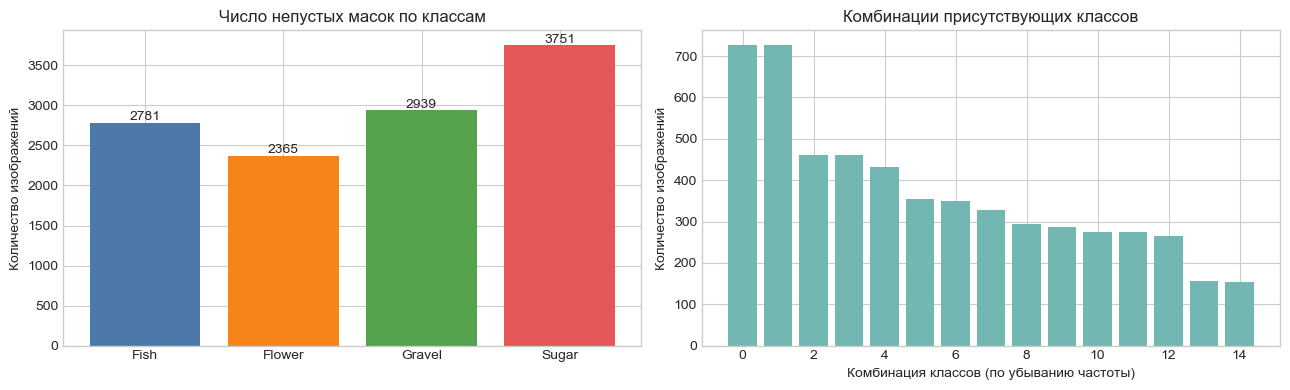

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

positive_counts = presence.sum().reindex(CLASSES)
axes[0].bar(CLASSES, positive_counts.values, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
axes[0].set_title("Число непустых масок по классам")
axes[0].set_ylabel("Количество изображений")
for i, value in enumerate(positive_counts.values):
    axes[0].text(i, value + 35, str(int(value)), ha="center")

combo_counts = image_df["stratum"].value_counts().sort_values(ascending=False)
axes[1].bar(range(len(combo_counts)), combo_counts.values, color="#72B7B2")
axes[1].set_title("Комбинации присутствующих классов")
axes[1].set_xlabel("Комбинация классов (по убыванию частоты)")
axes[1].set_ylabel("Количество изображений")

plt.tight_layout()
plt.show()

### Наблюдения по данным

- Разметка несбалансирована: `Sugar` встречается чаще остальных, `Flower` — реже.
- На одном изображении могут присутствовать несколько классов, поэтому выходные каналы независимы и применяется `sigmoid`, а не `softmax`.
- Исходные изображения имеют размер 2100×1400. Для учебного эксперимента они уменьшаются до 192×128 на CUDA или до 160×96 в CPU fallback; это ускоряет обучение, но стирает мелкие детали и является главным ограничением текущего эксперимента.

## 3. Декодирование RLE и визуальная проверка

Kaggle-RLE здесь нумерует пиксели с единицы и разворачивает маску по столбцам. Поэтому одномерный массив преобразуется через `reshape(width, height).T`. Визуальная проверка ниже важна: неверный порядок осей дал бы формально работающий, но обучающийся на повернутых масках пайплайн.

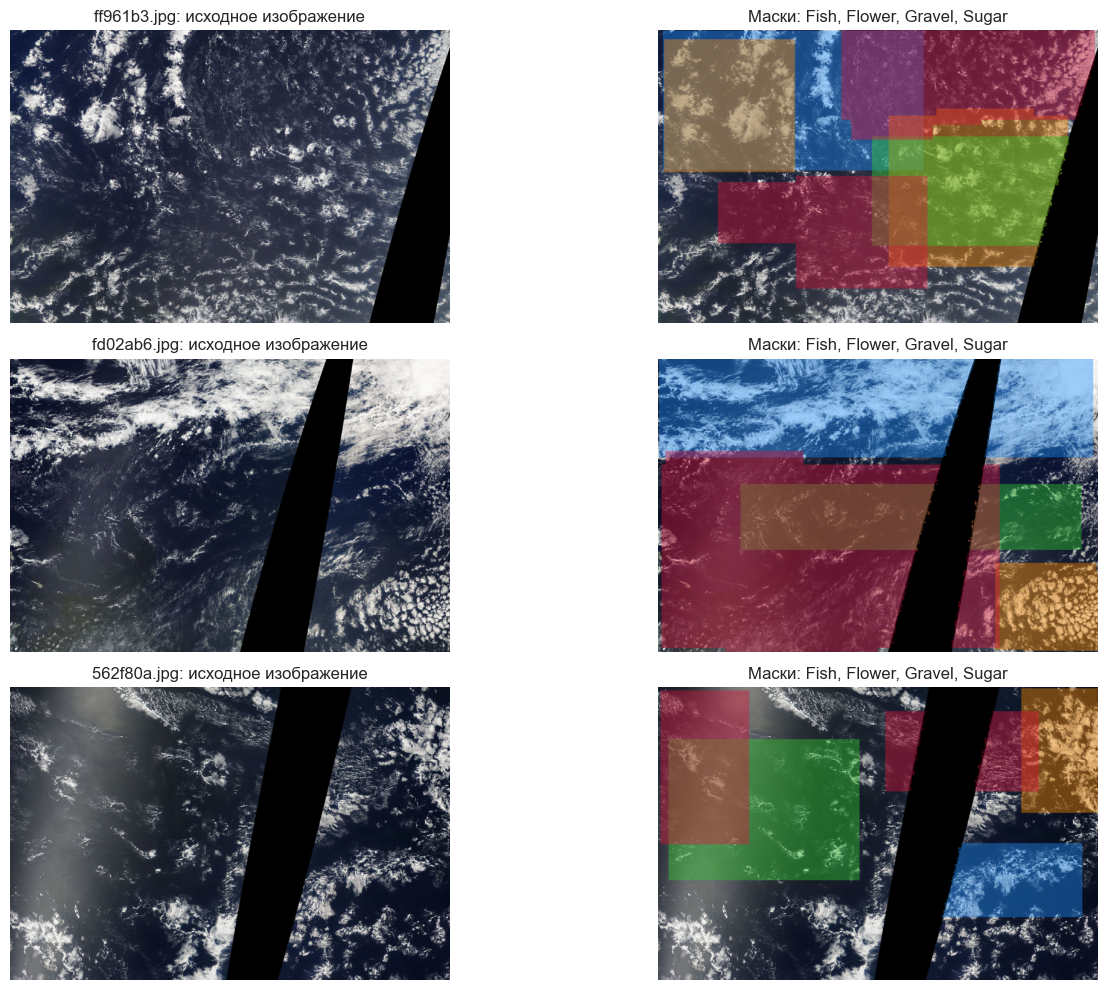

In [4]:
def rle_decode(rle, shape=(ORIGINAL_HEIGHT, ORIGINAL_WIDTH)):
    '''Преобразует Kaggle RLE в бинарную маску размера (height, width).'''
    height, width = shape
    mask = np.zeros(height * width, dtype=np.uint8)
    if pd.isna(rle) or str(rle).strip() == "":
        return mask.reshape((width, height)).T

    values = np.asarray(str(rle).split(), dtype=np.int64)
    starts = values[0::2] - 1
    lengths = values[1::2]
    for start, length in zip(starts, lengths):
        mask[start:start + length] = 1
    return mask.reshape((width, height)).T


def resize_mask(mask, size=IMAGE_SIZE):
    height, width = size
    return np.asarray(
        Image.fromarray(mask).resize((width, height), resample=Image.Resampling.NEAREST),
        dtype=np.uint8,
    )


def show_annotated_sample(row, alpha=0.42):
    image = np.asarray(Image.open(TRAIN_DIR / row["image"]).convert("RGB"))
    colors = np.array([[30, 144, 255], [255, 140, 0], [50, 205, 50], [220, 20, 60]], dtype=np.float32)
    overlay = image.astype(np.float32).copy()
    for i, class_name in enumerate(CLASSES):
        mask = rle_decode(row[class_name]).astype(bool)
        overlay[mask] = (1 - alpha) * overlay[mask] + alpha * colors[i]
    return image, overlay.astype(np.uint8)


positive_per_image = presence.sum(axis=1)
sample_names = positive_per_image.sort_values(ascending=False).head(3).index.tolist()
sample_rows = image_df.set_index("image").loc[sample_names].reset_index()

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(15, 10))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    image, overlay = show_annotated_sample(row)
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"{row['image']}: исходное изображение")
    axes[i, 1].imshow(overlay)
    labels = [c for c in CLASSES if pd.notna(row[c])]
    axes[i, 1].set_title("Маски: " + ", ".join(labels))
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

## 4. Разбиение и `Dataset`

Разбиение выполняется **по изображениям**, поэтому маски одного снимка не могут попасть одновременно в train и validation. Стратификация сохраняет распределение всех 15 наблюдаемых комбинаций классов. В `FAST_RUN` из каждой части берётся стратифицированная подвыборка.

Аугментации (горизонтальное и вертикальное отражение) синхронно применяются к изображению и маскам. Уменьшенные массивы кэшируются в RAM после первого чтения, что ускоряет следующие эпохи.

In [5]:
train_df, val_df = train_test_split(
    image_df,
    test_size=0.20,
    random_state=SEED,
    stratify=image_df["stratum"],
)


def stratified_subset(frame, n, seed):
    if n is None or n >= len(frame):
        return frame.reset_index(drop=True)
    subset, _ = train_test_split(
        frame,
        train_size=n,
        random_state=seed,
        stratify=frame["stratum"],
    )
    return subset.reset_index(drop=True)


if FAST_RUN:
    train_df = stratified_subset(train_df, TRAIN_SAMPLES, SEED)
    val_df = stratified_subset(val_df, VAL_SAMPLES, SEED + 1)
else:
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}; validation: {len(val_df):,}")
print("Train strata:", train_df["stratum"].value_counts(normalize=True).sort_index().round(3).to_dict())
print("Val strata:  ", val_df["stratum"].value_counts(normalize=True).sort_index().round(3).to_dict())

Train: 512; validation: 128
Train strata: {'0001': 0.078, '0010': 0.053, '0011': 0.131, '0100': 0.064, '0101': 0.084, '0110': 0.027, '0111': 0.062, '1000': 0.049, '1001': 0.084, '1010': 0.049, '1011': 0.131, '1100': 0.053, '1101': 0.059, '1110': 0.027, '1111': 0.049}
Val strata:   {'0001': 0.078, '0010': 0.047, '0011': 0.133, '0100': 0.062, '0101': 0.086, '0110': 0.031, '0111': 0.062, '1000': 0.047, '1001': 0.086, '1010': 0.047, '1011': 0.133, '1100': 0.055, '1101': 0.062, '1110': 0.023, '1111': 0.047}


In [6]:
class CloudDataset(Dataset):
    def __init__(self, frame, image_dir, image_size=IMAGE_SIZE, augment=False, cache=True):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.image_size = image_size
        self.augment = augment
        self.cache = {} if cache else None

    def __len__(self):
        return len(self.frame)

    def _read_and_resize(self, idx):
        row = self.frame.iloc[idx]
        target_h, target_w = self.image_size
        image = Image.open(self.image_dir / row["image"]).convert("RGB")
        image = np.asarray(
            image.resize((target_w, target_h), resample=Image.Resampling.BILINEAR),
            dtype=np.uint8,
        )

        masks = []
        for class_name in CLASSES:
            mask = rle_decode(row[class_name])
            masks.append(resize_mask(mask, self.image_size))
        masks = np.stack(masks, axis=0).astype(np.uint8)
        return image, masks

    def __getitem__(self, idx):
        if self.cache is not None and idx in self.cache:
            image, masks = self.cache[idx]
        else:
            image, masks = self._read_and_resize(idx)
            if self.cache is not None:
                self.cache[idx] = (image, masks)

        # copy обязателен: отражённые NumPy-массивы имеют отрицательные strides.
        if self.augment and random.random() < 0.5:
            image = np.flip(image, axis=1).copy()
            masks = np.flip(masks, axis=2).copy()
        if self.augment and random.random() < 0.5:
            image = np.flip(image, axis=0).copy()
            masks = np.flip(masks, axis=1).copy()

        image_t = torch.from_numpy(image.copy()).permute(2, 0, 1).float().div_(255.0)
        mask_t = torch.from_numpy(masks.copy()).float()
        return image_t, mask_t, self.frame.iloc[idx]["image"]


train_ds = CloudDataset(train_df, TRAIN_DIR, augment=True, cache=True)
val_ds = CloudDataset(val_df, TRAIN_DIR, augment=False, cache=True)

pin_memory = device.type == "cuda"
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)

images, masks, names = next(iter(train_loader))
print("Batch images:", tuple(images.shape), images.dtype, f"range=({images.min():.2f}, {images.max():.2f})")
print("Batch masks: ", tuple(masks.shape), masks.dtype, "values=", torch.unique(masks).tolist())
assert images.shape[1:] == (3, *IMAGE_SIZE)
assert masks.shape[1:] == (len(CLASSES), *IMAGE_SIZE)

Batch images: (8, 3, 96, 160) torch.float32 range=(0.00, 1.00)
Batch masks:  (8, 4, 96, 160) torch.float32 values= [0.0, 1.0]


## 5. Сверточная сеть Mini U-Net

Архитектура U-Net подходит для сегментации, потому что энкодер извлекает контекст, а skip connections возвращают в декодер пространственные детали. Здесь используется компактная версия:

1. два уровня энкодера с `MaxPool2d`;
2. bottleneck;
3. два уровня декодера с транспонированными свертками;
4. skip connections и выход `1×1 Conv` на четыре логита.

`GroupNorm` устойчив при небольших batch size. Последний слой не содержит `sigmoid`: для численной устойчивости `BCEWithLogitsLoss` получает логиты напрямую.

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        groups = 4 if out_channels >= 4 else 1
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class MiniUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=4, base=16):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base * 2, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


model = MiniUNet(base=BASE_CHANNELS).to(device)
parameter_count = sum(p.numel() for p in model.parameters())
with torch.no_grad():
    test_output = model(torch.zeros(2, 3, *IMAGE_SIZE, device=device))
print(model)
print(f"Обучаемых параметров: {parameter_count:,}")
print("Проверка формы выхода:", tuple(test_output.shape))
assert test_output.shape == (2, len(CLASSES), *IMAGE_SIZE)
del test_output
if device.type == "cuda":
    torch.cuda.empty_cache()

MiniUNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(4, 8, eps=1e-05, affine=True, bias=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): GroupNorm(4, 8, eps=1e-05, affine=True, bias=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(4, 16, eps=1e-05, affine=True, bias=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): GroupNorm(4, 16, eps=1e-05, affine=True, bias=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv2d(16

## 6. Loss и Dice coefficient

Для бинарных масок $p$ и $y$ коэффициент Dice:

$$\operatorname{Dice}(p,y)=\frac{2\sum_i p_i y_i + \varepsilon}{\sum_i p_i + \sum_i y_i + \varepsilon}.$$

На обучении используется дифференцируемый Soft Dice по вероятностям. Итоговая loss — сумма взвешенного `BCEWithLogitsLoss` и Soft Dice loss. `pos_weight` вычисляется только на train-пикселях и ограничивается сверху значением 10: это не даёт модели получить хороший результат простым предсказанием пустых масок. BCE обеспечивает устойчивый попиксельный сигнал, а Dice компенсирует сильный дисбаланс между фоном и облаками.

Валидационная метрика вычисляется после порога 0.5 по всем пикселям validation отдельно для каждого класса, затем берётся macro-average четырёх классов. Dataset-level агрегация не позволяет искусственно повысить оценку большим числом пустых пар «изображение–класс». Если некоторого класса нет во всей выборке и модель также его не предсказывает, сглаживание задаёт Dice равным 1.

In [8]:
EPS = 1e-6

# Одновременно вычисляем train-only статистику и заполняем RAM-кэш датасета.
positive_pixels = torch.zeros(len(CLASSES), dtype=torch.float64)
total_pixels_per_class = 0
for _, batch_masks, _ in train_loader:
    positive_pixels += batch_masks.sum(dim=(0, 2, 3)).double()
    total_pixels_per_class += batch_masks.shape[0] * batch_masks.shape[2] * batch_masks.shape[3]

pixel_prevalence = (positive_pixels / total_pixels_per_class).float()
pos_weight = ((1.0 - pixel_prevalence) / pixel_prevalence.clamp_min(EPS)).clamp(1.0, 10.0).to(device)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight.view(1, -1, 1, 1))
pixel_stats = pd.DataFrame({
    "pixel_prevalence": pixel_prevalence.numpy(),
    "BCE_pos_weight": pos_weight.cpu().numpy(),
}, index=CLASSES)
display(pixel_stats.style.format({"pixel_prevalence": "{:.2%}", "BCE_pos_weight": "{:.2f}"}))


def soft_dice_loss(logits, targets, eps=EPS):
    probabilities = torch.sigmoid(logits)
    dims = (0, 2, 3)
    intersection = (probabilities * targets).sum(dims)
    denominator = probabilities.sum(dims) + targets.sum(dims)
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()


def combined_loss(logits, targets):
    return bce_loss(logits, targets) + soft_dice_loss(logits, targets)


@torch.no_grad()
def dice_per_sample_class(logits, targets, threshold=0.5, eps=EPS):
    predictions = (torch.sigmoid(logits) >= threshold).float()
    intersection = (predictions * targets).sum(dim=(2, 3))
    denominator = predictions.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    return (2.0 * intersection + eps) / (denominator + eps)


# Мини-тест метрики: пусто/пусто -> 1; идеальное совпадение -> 1.
empty_logits = torch.full((1, 4, 2, 2), -20.0)
empty_targets = torch.zeros((1, 4, 2, 2))
perfect_logits = torch.where(empty_targets > 0, 20.0, -20.0)
assert torch.allclose(dice_per_sample_class(empty_logits, empty_targets), torch.ones(1, 4))
assert torch.allclose(dice_per_sample_class(perfect_logits, empty_targets), torch.ones(1, 4))
print("Проверки Dice пройдены.")

,pixel_prevalence,BCE_pos_weight
Fish,15.02%,5.66
Flower,13.30%,6.52
Gravel,15.38%,5.50
Sugar,15.89%,5.29


Проверки Dice пройдены.


## 7. Обучение и ранняя остановка

Ранняя остановка отслеживает **максимум validation Dice**. При улучшении метрики сохраняется checkpoint; если улучшения больше `min_delta` нет `patience` эпох подряд, цикл прерывается. Дополнительно применяются `AdamW`, weight decay, аугментации и clipping нормы градиента — это снижает переобучение и риск нестабильных градиентов.

In [9]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=1e-4, path=CHECKPOINT_PATH):
        self.patience = patience
        self.min_delta = min_delta
        self.path = Path(path)
        self.best_score = -np.inf
        self.counter = 0
        self.best_epoch = 0
        self.early_stop = False

    def __call__(self, score, model, epoch):
        if score > self.best_score + self.min_delta:
            self.best_score = float(score)
            self.best_epoch = int(epoch)
            self.counter = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "val_dice": float(score),
                    "classes": CLASSES,
                    "image_size": IMAGE_SIZE,
                    "base_channels": BASE_CHANNELS,
                },
                self.path,
            )
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.early_stop = True
        return False


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    running_loss = 0.0
    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = combined_loss(logits, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    intersection_sum = torch.zeros(len(CLASSES), device=device)
    prediction_sum = torch.zeros(len(CLASSES), device=device)
    target_sum = torch.zeros(len(CLASSES), device=device)
    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = combined_loss(logits, masks)
        predictions = (torch.sigmoid(logits) >= 0.5).float()
        running_loss += loss.item() * images.size(0)
        intersection_sum += (predictions * masks).sum(dim=(0, 2, 3))
        prediction_sum += predictions.sum(dim=(0, 2, 3))
        target_sum += masks.sum(dim=(0, 2, 3))
    per_class = ((2.0 * intersection_sum + EPS) / (prediction_sum + target_sum + EPS)).cpu().numpy()
    return running_loss / len(loader.dataset), float(per_class.mean()), per_class

In [10]:
# Повторная инициализация гарантирует, что тестовый forward не влияет на эксперимент.
torch.manual_seed(SEED)
model = MiniUNet(base=BASE_CHANNELS).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1, min_lr=1e-5
)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
early_stopping = EarlyStopping(patience=PATIENCE)

history = {
    "train_loss": [], "val_loss": [], "val_dice": [],
    "lr": [], "epoch_seconds": [], "per_class": [],
}

training_started = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    epoch_started = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
    val_loss, val_dice, per_class = validate(model, val_loader)
    scheduler.step(val_dice)
    improved = early_stopping(val_dice, model, epoch)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["epoch_seconds"].append(time.time() - epoch_started)
    history["per_class"].append(per_class)

    class_text = ", ".join(f"{c}={d:.3f}" for c, d in zip(CLASSES, per_class))
    marker = "  * best" if improved else ""
    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f} | val Dice {val_dice:.4f} | {class_text} | "
        f"{history['epoch_seconds'][-1]:.1f}s{marker}"
    )

    if early_stopping.early_stop:
        print(f"Ранняя остановка: {PATIENCE} эпох без значимого улучшения.")
        break

total_minutes = (time.time() - training_started) / 60
print(f"Обучение завершено за {total_minutes:.1f} мин.")
print(f"Лучшая эпоха: {early_stopping.best_epoch}; лучший validation Dice: {early_stopping.best_score:.4f}")
assert CHECKPOINT_PATH.exists(), "Checkpoint лучшей модели не был сохранён"

Epoch 01/15 | train loss 1.9072 | val loss 1.8556 | val Dice 0.3263 | Fish=0.299, Flower=0.315, Gravel=0.313, Sugar=0.378 | 40.0s  * best
Epoch 02/15 | train loss 1.8263 | val loss 1.8106 | val Dice 0.3377 | Fish=0.307, Flower=0.336, Gravel=0.305, Sugar=0.403 | 14.6s  * best
Epoch 03/15 | train loss 1.7886 | val loss 1.7869 | val Dice 0.3390 | Fish=0.303, Flower=0.339, Gravel=0.298, Sugar=0.417 | 13.2s  * best
Epoch 04/15 | train loss 1.7619 | val loss 1.7632 | val Dice 0.3494 | Fish=0.305, Flower=0.356, Gravel=0.322, Sugar=0.414 | 13.9s  * best
Epoch 05/15 | train loss 1.7476 | val loss 1.7613 | val Dice 0.3529 | Fish=0.299, Flower=0.345, Gravel=0.333, Sugar=0.435 | 13.2s  * best
Epoch 06/15 | train loss 1.7347 | val loss 1.7290 | val Dice 0.3677 | Fish=0.321, Flower=0.380, Gravel=0.329, Sugar=0.441 | 13.5s  * best
Epoch 07/15 | train loss 1.7187 | val loss 1.7292 | val Dice 0.3701 | Fish=0.304, Flower=0.369, Gravel=0.333, Sugar=0.474 | 13.9s  * best
Epoch 08/15 | train loss 1.7114 | 

Epoch 02/15 | train loss 1.8263 | val loss 1.8106 | val Dice 0.3377 | Fish=0.307, Flower=0.336, Gravel=0.305, Sugar=0.403 | 2.8s  * best


Epoch 03/15 | train loss 1.7886 | val loss 1.7869 | val Dice 0.3390 | Fish=0.303, Flower=0.339, Gravel=0.298, Sugar=0.417 | 2.9s  * best


Epoch 04/15 | train loss 1.7619 | val loss 1.7632 | val Dice 0.3494 | Fish=0.305, Flower=0.356, Gravel=0.322, Sugar=0.414 | 2.9s  * best


Epoch 05/15 | train loss 1.7476 | val loss 1.7613 | val Dice 0.3529 | Fish=0.299, Flower=0.345, Gravel=0.333, Sugar=0.435 | 2.9s  * best


...

Epoch 11/15 | train loss 1.6966 | val loss 1.7537 | val Dice 0.3677 | Fish=0.292, Flower=0.361, Gravel=0.330, Sugar=0.488 | 2.9s


Epoch 12/15 | train loss 1.6927 | val loss 1.6725 | val Dice 0.3829 | Fish=0.305, Flower=0.421, Gravel=0.335, Sugar=0.471 | 2.8s


Epoch 13/15 | train loss 1.6841 | val loss 1.6887 | val Dice 0.3860 | Fish=0.305, Flower=0.394, Gravel=0.348, Sugar=0.497 | 2.9s  * best


Epoch 14/15 | train loss 1.6629 | val loss 1.6629 | val Dice 0.3908 | Fish=0.306, Flower=0.424, Gravel=0.350, Sugar=0.483 | 2.8s  * best


Epoch 15/15 | train loss 1.6510 | val loss 1.6798 | val Dice 0.3897 | Fish=0.296, Flower=0.490, Gravel=0.345, Sugar=0.428 | 2.8s
Обучение завершено за 0.9 мин.
Лучшая эпоха: 14; лучший validation Dice: 0.3908


## 8. Графики обучения

Слева показаны train/validation loss, справа — основной критерий validation Dice. Вертикальная линия отмечает эпоху, checkpoint которой сохранён. Разница loss между train и validation допустима: в train включены случайные аугментации.

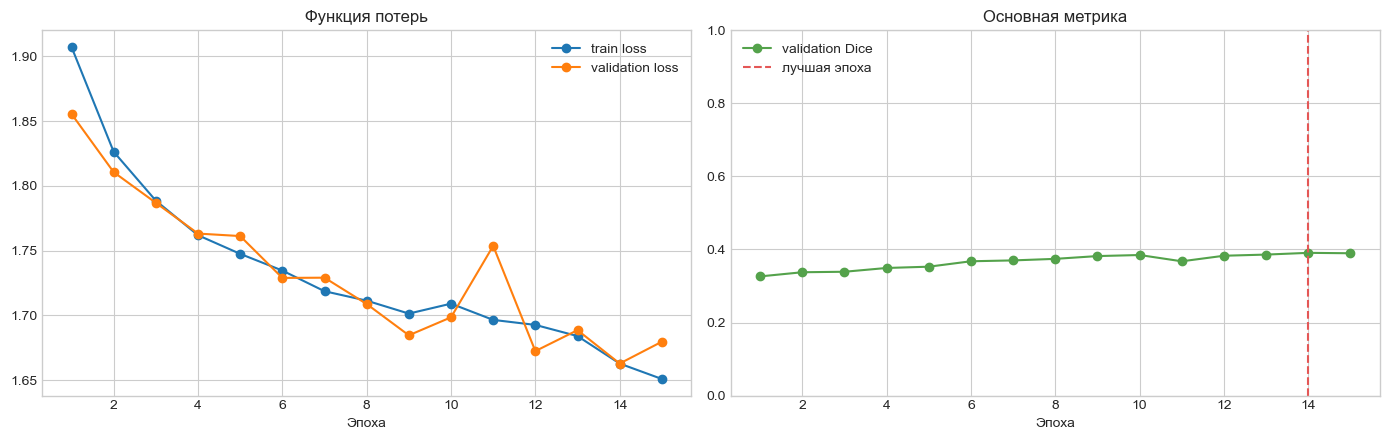

In [11]:
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
axes[0].plot(epochs, history["val_loss"], marker="o", label="validation loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_title("Функция потерь")
axes[0].legend()

axes[1].plot(epochs, history["val_dice"], marker="o", color="#54A24B", label="validation Dice")
axes[1].axvline(early_stopping.best_epoch, color="#E45756", linestyle="--", label="лучшая эпоха")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylim(0, 1)
axes[1].set_title("Основная метрика")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Оценка лучшей модели

Для финальной оценки загружается именно сохранённый checkpoint, а не состояние последней эпохи. Помимо среднего Dice выводится метрика для каждого класса и несколько предсказаний.

In [12]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
final_val_loss, final_val_dice, final_per_class = validate(model, val_loader)
# Для dataset-level Dice пустой прогноз получает 0 для каждого представленного класса.
empty_baseline = float((val_df[CLASSES].notna().sum(axis=0) == 0).mean())

results = pd.DataFrame({
    "class": CLASSES,
    "Dice@0.5": final_per_class,
}).set_index("class")

print(f"Checkpoint эпохи: {checkpoint['epoch']}")
print(f"Validation loss: {final_val_loss:.4f}")
print(f"Mean validation Dice@0.5: {final_val_dice:.4f}")
print(f"Пустой baseline Dice: {empty_baseline:.4f}")
print(f"Прирост над пустым baseline: {final_val_dice - empty_baseline:+.4f}")
results.style.format("{:.4f}").background_gradient(cmap="YlGn", vmin=0, vmax=1)

Checkpoint эпохи: 14
Validation loss: 1.6629
Mean validation Dice@0.5: 0.3908
Пустой baseline Dice: 0.0000
Прирост над пустым baseline: +0.3908


,Dice@0.5
class,
Fish,0.3063
Flower,0.4240
Gravel,0.3502
Sugar,0.4828


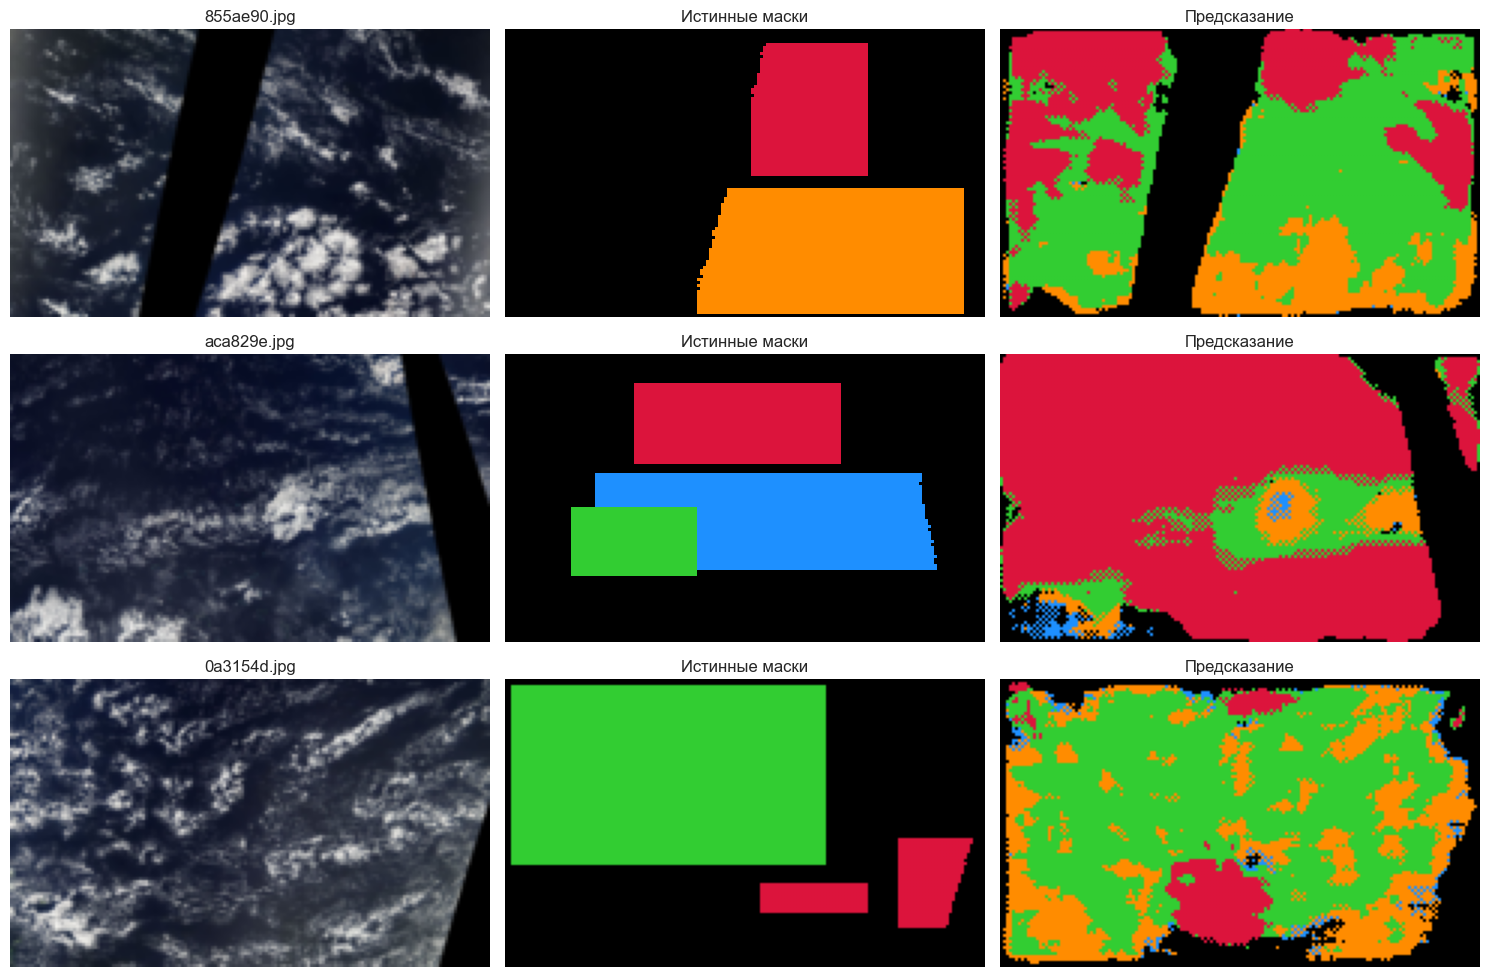

In [13]:
@torch.no_grad()
def collect_examples(model, dataset, indices):
    model.eval()
    rows = []
    for idx in indices:
        image_t, mask_t, name = dataset[idx]
        logits = model(image_t.unsqueeze(0).to(device))
        prediction = (torch.sigmoid(logits)[0].cpu() >= 0.5).numpy()
        rows.append((image_t.permute(1, 2, 0).numpy(), mask_t.numpy(), prediction, name))
    return rows


example_indices = np.linspace(0, len(val_ds) - 1, 3, dtype=int)
examples = collect_examples(model, val_ds, example_indices)

fig, axes = plt.subplots(len(examples), 3, figsize=(15, 10))
colors = np.array([[30, 144, 255], [255, 140, 0], [50, 205, 50], [220, 20, 60]], dtype=np.float32) / 255

def colored_mask(mask_stack):
    canvas = np.zeros((*mask_stack.shape[1:], 3), dtype=np.float32)
    for class_idx in range(len(CLASSES)):
        canvas[mask_stack[class_idx].astype(bool)] = colors[class_idx]
    return canvas

for row_idx, (image, target, prediction, name) in enumerate(examples):
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(name)
    axes[row_idx, 1].imshow(colored_mask(target))
    axes[row_idx, 1].set_title("Истинные маски")
    axes[row_idx, 2].imshow(colored_mask(prediction))
    axes[row_idx, 2].set_title("Предсказание")
    for ax in axes[row_idx]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Вывод

**Что именно решает сеть?**  Не классификацию целого снимка, а сегментацию четырёх типов облачной организации. На выходе для каждого изображения получается четыре карты вероятностей того же пространственного размера, что и уменьшенная входная картинка.

**Почему `sigmoid`, а не `softmax`?**  Классы не являются взаимоисключающими: один снимок и даже отдельные области могут иметь несколько меток. `Sigmoid` оценивает каждый выходной канал независимо.

**Почему выбрана U-Net?**  Сегментации одновременно нужны глобальный контекст и точная локализация. Энкодер накапливает контекст, декодер восстанавливает разрешение, а skip connections передают детали и улучшают прохождение градиента.

**Почему loss состоит из BCE и Dice?**  Фон занимает большую часть изображения. BCE с вычисленным на train `pos_weight` даёт устойчивый попиксельный градиент и штрафует пропуск редких положительных пикселей, а Dice непосредственно оптимизирует перекрытие областей и меньше зависит от дисбаланса площадей.

**Как оценивается качество?**  Основная метрика — macro-average hard Dice при пороге 0.5: пересечение и площади суммируются по всем validation-пикселям отдельно для каждого класса, после чего четыре значения усредняются. Также выведены Dice для каждого класса и пустой baseline. Для честной оценки train и validation разделены по изображениям.

**Как реализована ранняя остановка?**  После каждой эпохи измеряется validation Dice. Лучшее состояние сохраняется в `best_cloud_unet.pt`; после `PATIENCE` эпох без улучшения более чем на `min_delta` обучение прекращается. Финальная оценка всегда делается из лучшего checkpoint.

**Как контролируются переобучение и нестабильные градиенты?**  Используются отражения, стратифицированное разбиение, `AdamW` с weight decay, `ReduceLROnPlateau`, `GroupNorm`, skip connections, gradient clipping и ранняя остановка. Mixed precision ускоряет CUDA-обучение, но не меняет постановку задачи.

**Главное ограничение эксперимента.**  `FAST_RUN` и уменьшенное разрешение позволяют воспроизводимо выполнить работу локально, однако уменьшают разнообразие примеров и теряют мелкие детали границ. Для итоговой соревновательной модели следует отключить `FAST_RUN`, увеличить разрешение (например, 320×480), использовать более глубокий U-Net/предобученный энкодер, cross-validation, подбор порогов и постобработку малых компонент.
